In [72]:
import numpy as np
import scipy
from scipy.sparse.linalg import spsolve
from matplotlib import pyplot as plt

In [73]:
def make_diff_opperator(m, Nx, Nz, h, omega):

	Nm = Nx*Nz

	# central node  # z-1 node  # z+1 node  # x-1 node  # x+1 node
	diags = [0, Nx, -Nx, 1, -1]

	J, I = np.meshgrid(np.arange(Nx), np.arange(Nz))
	I = I.flatten()
	J = J.flatten()
	c2_flat = m.flatten()**2

	bol_top = I == 0
	bol_btm = I == Nz-1
	bol_lft = J == 0
	bol_rht = J == Nx-1
	bol_int = (bol_top + bol_btm + bol_lft + bol_rht) == 0

	# initialize diagonals
	D = np.zeros((5, Nm), dtype=complex)

	# set central stencils
	D[0,:][bol_int] = -4 * c2_flat[bol_int] / (h**2) + 1.0*(omega**2)       
	D[1,:][bol_int] = 1.0 * c2_flat[bol_int] / (h**2)                       
	D[2,:][bol_int] = 1.0 * c2_flat[bol_int] / (h**2)                      
	D[3,:][bol_int] = 1.0 * c2_flat[bol_int] / (h**2)                      
	D[4,:][bol_int] = 1.0 * c2_flat[bol_int] / (h**2)                      

	# set right boundary condition
	D[0,:][bol_rht] += -1.0/h - 1j*omega / np.sqrt(c2_flat[bol_rht])
	D[4,:][bol_rht] += +1.0/h
	D[4,:] = np.roll(D[4,:],-1)

	# set bottom boundary condition
	D[0,:][bol_btm] += -1.0/h - 1j*omega / np.sqrt(c2_flat[bol_btm])
	D[2,:][bol_btm] += +1.0/h
	D[2,:] = np.roll(D[2,:], -(Nx))

	# set left boundary condition
	D[0,:][bol_lft] += -1.0/h - 1j*omega / np.sqrt(c2_flat[bol_lft])
	D[3,:][bol_lft] += +1.0/h
	D[3,:] = np.roll(D[3,:],1)

	# set top boundary condition
	D[0,:][bol_top] += -1.0/h - 1j*omega / np.sqrt(c2_flat[bol_top])
	D[1,:][bol_top] += +1.0/h
	D[1,:] = np.roll(D[1,:], Nx)

	return scipy.sparse.spdiags(D, diags, Nm, Nm, format="csr")

def wrap(y): 
	return ((y + np.pi) % (2*np.pi)) - np.pi

def unwrap(Psi, s_x_ind, s_z_ind):

	Ny = Psi.shape[0]
	Nx = Psi.shape[1]
	Nm = Nx * Ny

	J, I = np.meshgrid(np.arange(Nx), np.arange(Ny))
	I = I.flatten()
	J = J.flatten()

	dx_psi = 0.0*Psi
	dx_psi[:,:-1] = wrap(np.diff(Psi, axis=1))
	dy_psi = 0.0*Psi
	dy_psi[:-1,:] = wrap(np.diff(Psi, axis=0))

	bol_btm = I == Ny-1
	bol_rht = J == Nx-1

	D1 = np.vstack((-np.ones((1, Nm)), np.ones((1, Nm)), np.zeros((1, Nm))))
	D1[0,:][bol_rht] = 1.0
	D1[1,:][bol_rht] = 0.0
	D1[2,:][bol_rht] = -1.0
	D1[1,:] = np.roll(D1[1,:], 1)
	D1[2,:] = np.roll(D1[2,:], -1)

	Dx = scipy.sparse.spdiags(D1, [0, 1, -1], Nm, Nm, format="csr")

	D2 = np.vstack((-np.ones((1, Nm)), np.ones((1, Nm)), np.zeros((1, Nm))))
	D2[0,:][bol_btm] = 1.0
	D2[1,:][bol_btm] = 0.0
	D2[2,:][bol_btm] = -1.0
	D2[1,:] = np.roll(D2[1,:], Nx)
	D2[2,:] = np.roll(D2[2,:], -Nx)

	Dy = scipy.sparse.spdiags(D2, [0, Nx, -Nx], Nm, Nm, format="csr")

	# form gadient opperator
	G = scipy.sparse.bmat([[Dx],[Dy]], format="csr")

	# I = scipy.sparse.spdiags(np.ones(Nm), [0], Nm, Nm, format="csr")

	d = np.hstack(
		(dx_psi.flatten(), dy_psi.flatten())
	)

	RHS = G.T@G #+ 1*I
	LHS = G.T@d
	Phi_star = spsolve(RHS, LHS)
	Phi_star = Phi_star.reshape(Psi.shape)
	Phi_star -= Phi_star[s_z_ind, s_x_ind]
	Phi_star += Psi[s_z_ind, s_x_ind]

	return Phi_star



Outline

1) Make true and inital models, source and reveiver geometry
2) Forward model the data with the using the true model
3) Do FWI starting with the initial model

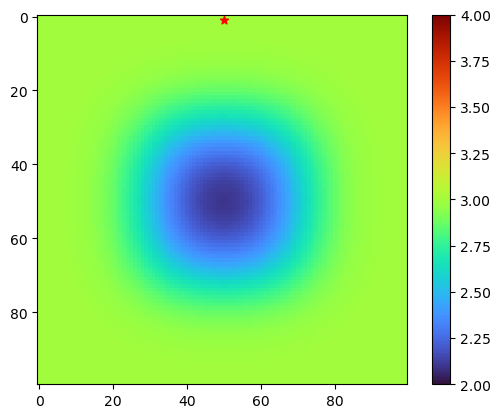

In [74]:
# Make true and inital models, source and receiver geometry

# create a spatial domain
Nx = 100
Nz = 100
Nm = Nx*Nz
h = 1.0
X, Z = np.meshgrid(np.arange(0, Nx*h, h), np.arange(0, Nz*h, h))

# make initial model
m1 = 3.0*np.ones((Nz,Nx))
c2_1 = m1**2

# make perturbed model
m2 = 1.0*m1

# m2[(X > 20) * (X < 50) * (Z > 20) * (Z < 50)] = 4.00
# m2[(X > 50) * (X < 80) * (Z > 20) * (Z < 50)] = 2.00
# m2[(X > 50) * (X < 80) * (Z > 50) * (Z < 80)] = 4.0
# m2[(X > 20) * (X < 50) * (Z > 50) * (Z < 80)] = 2.0

m2[(X > 30) * (X < 70) * (Z > 30) * (Z < 70)] = 2.0
m2 = scipy.ndimage.gaussian_filter(m2, sigma=10)

# bol = (X-50)**2 + (Z-50)**2 < 5**2
# m2[bol] = 4.0
# m2 = scipy.ndimage.gaussian_filter(m2, sigma=4)

# get receiver locations
r_x_inds, r_z_inds = np.meshgrid(np.arange(1, Nx-1, 1), np.arange(1, Nz-1, 1))
Nrz = r_x_inds.shape[0]
Nrx = r_x_inds.shape[1]

r_x_inds = r_x_inds.flatten()
r_z_inds = r_z_inds.flatten()
Nr = len(r_x_inds)

# get source locations
s_x_inds = r_x_inds[49:50]
s_z_inds = r_z_inds[49:50]
# s_z_inds = r_z_inds[0]
# s_x_inds = r_x_inds[0]
# s_x_inds, s_z_inds = np.meshgrid(np.arange(1, Nx-1, 12), np.arange(1, Nz-1, 12))
s_x_inds = s_x_inds.flatten()
s_z_inds = s_z_inds.flatten()
Ns = len(s_x_inds)

plt.imshow(m2, cmap="turbo", vmin=2.0, vmax=4.0)
# plt.pcolor(X, Z, m2, cmap="gray")
plt.colorbar()
# plt.show()
# plt.scatter(r_x_inds*h, r_z_inds*h)
plt.scatter(s_x_inds*h, s_z_inds*h, marker="*", c="r")


In [75]:
# Define the freqeuncies that we will model
lambda_min = h*12.0
freq_min = 0.17#0.13
N_freq = 1#5 
df = 0.01
freqs = np.arange(N_freq)*df + freq_min
print(np.min(m2) / lambda_min)
if np.max(freqs) > np.min(m2) / lambda_min:
	raise(ValueError)

print(freqs)

# Forward model the data with the using the true model

# initialize array of observed dat
dat_OBS = np.zeros((Nr, Ns, N_freq), dtype=complex)

for k in range(N_freq):

	# get wave propogator matrix
	omega = freqs[k]*2*np.pi
	A = make_diff_opperator(m2, Nx, Nz, h, omega)

	# Set up source Matrix
	f = np.zeros((Nm, Ns), dtype=complex)
	for i in range(Ns): 
		global_ind = np.ravel_multi_index((int(s_z_inds[i]), int(s_x_inds[i])), (Nz, Nx))
		f[global_ind, i] = 1.0

	# solve linear system
	u = spsolve(A, f).reshape((Nm, Ns))

	# pull out OBS data
	for i in range(Nr): 
		for j in range(Ns): 
			global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
			dat_OBS[i,j,k] = u[global_ind,j] 



0.17495482695882916
[0.17]


Text(0.5, 1.0, 'Unwrapped Phase')

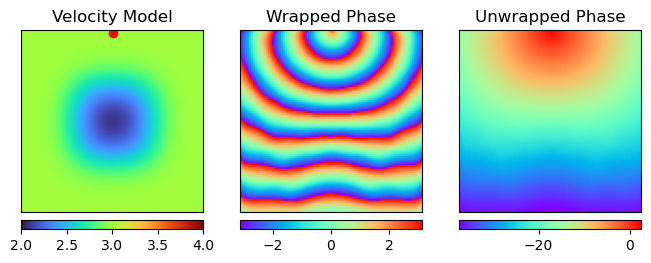

In [77]:
# phase unrwapp the data

psi = dat_OBS[:,0,-1].reshape(Nrz, Nrx)
psi0 = np.angle(psi)
phi = unwrap(psi0, s_x_inds[0], s_z_inds[0])

fig, ax = plt.subplots(1, 3, figsize=(8,4))

im1 = ax[0].imshow(m2, cmap="turbo", vmin=2.0, vmax=4.0)
ax[0].set_xticks([])
ax[0].set_yticks([])
fig.colorbar(im1, ax=ax[0], location="bottom", pad=0.025)
ax[0].set_title("Velocity Model")
ax[0].scatter(s_x_inds*h, s_z_inds*h, marker="o", c="r")

im2 = ax[1].imshow(psi0, cmap="rainbow")
ax[1].set_xticks([])
ax[1].set_yticks([])
fig.colorbar(im2, ax=ax[1], location="bottom", pad=0.025)
ax[1].set_title("Wrapped Phase")

im3 = ax[2].imshow(phi, cmap="rainbow")
ax[2].set_xticks([])
ax[2].set_yticks([])
fig.colorbar(im3, ax=ax[2], location="bottom", pad=0.025)
ax[2].set_title("Unwrapped Phase")

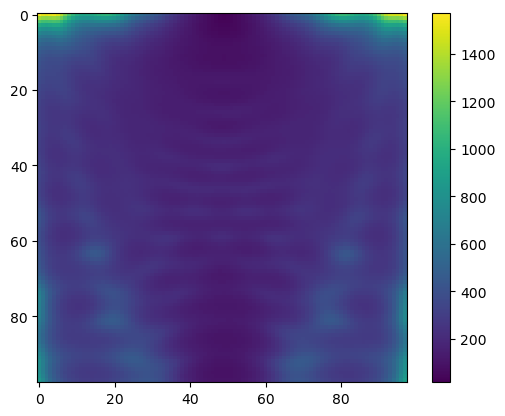

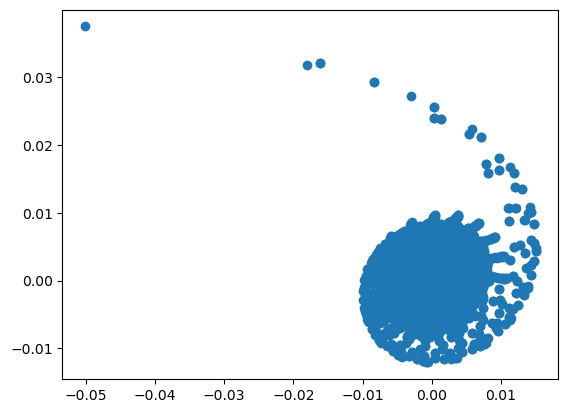

In [78]:
u = dat_OBS[:,0,-1].reshape(Nrz, Nrx)

plt.imshow(np.abs(1/(u+0.0*np.min(u.real))))
plt.colorbar()
plt.show()


plt.scatter(u.real, u.imag)
# plt.xlim(-0.0001, 0.0001)
# plt.ylim(-0.0001, 0.0001)

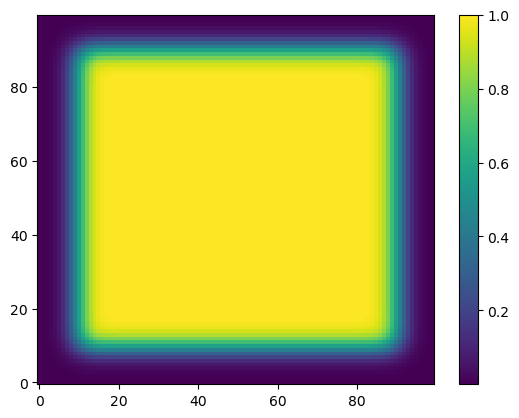

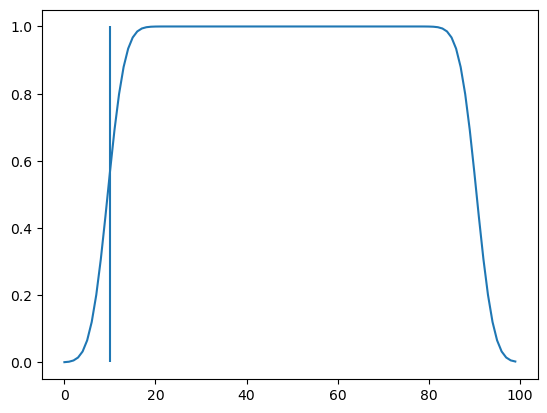

In [79]:
# make preconditioner

P0 = np.ones((Nz, Nx))
P0[(X < 10)] = 0.0
P0[(Z < 10)] = 0.0
P0[(X > 90)] = 0.0
P0[(Z > 90)] = 0.0
P0 = scipy.ndimage.gaussian_filter(P0, sigma=3)

# plt.imshow(P0)
plt.pcolor(X, Z, P0)
plt.colorbar()
plt.show()
plt.plot(P0[50, :])
plt.vlines(10, 0.0, 1.0)

In [48]:
# compute one phase unwrapped gradient

m = 1.0*m1

# initialize array of predicted dat
dat_SYN = np.zeros((Nr, Ns, N_freq), dtype=complex)
resid = np.zeros((Nr, Ns, N_freq), dtype=complex)

G = np.zeros(m.shape)

for k in range(N_freq):

	# get wavefield propogator matrix
	omega = freqs[k]*2*np.pi
	A = make_diff_opperator(m, Nx, Nz, h, omega)

	# Set up source Matrix
	f = np.zeros((Nm, Ns), dtype=complex)
	for i in range(Ns): 
		global_ind = np.ravel_multi_index((int(s_z_inds[i]), int(s_x_inds[i])), (Nz, Nx))
		f[global_ind, i] = 1.0

	# compute forward wavefield
	u = spsolve(A, f).reshape((Nm, Ns))

	# pull out predicted data
	for i in range(Nr): 
		for j in range(Ns): 
			global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
			dat_SYN[i,j,k] = u[global_ind,j] 
			
	# unwrap data
	for j in range(Ns):
		psi = np.angle((dat_SYN[:,j,k])*np.conj(dat_OBS[:,j,k])).reshape(Nrz, Nrx)
		phi = unwrap(psi, s_x_inds[j], s_z_inds[j])
		# phi = 1.0*psi
		resid[:,j,k] = phi.flatten()
	
	# populate and adjoint source
	f_adj = np.zeros((Nm, Ns), dtype=complex)
	for i in range(Nr): 
		for j in range(Ns): 
			global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
			f_adj[global_ind,j] = np.conj(resid[i,j,k]/(dat_SYN[i,j,k]))

	# compute adjoint wavefield
	u_adj = spsolve(np.conj(A.T), f_adj).reshape((Nm, Ns))

	# correlate and sum over the forward and adjoint wavefields
	g_temp = np.sum(np.conj(u_adj) * u, axis=1)

	G += g_temp.reshape(m.shape).imag  * 2.0 * (omega**2) * (m**3)

G *= P0

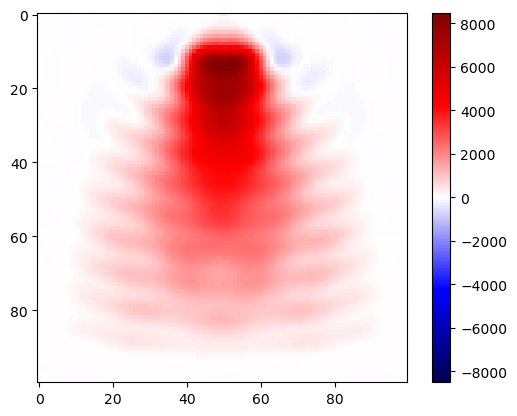

In [50]:
plt.imshow(G, vmin=-np.max(np.abs(G)), vmax=np.max(np.abs(G)), cmap="seismic")
plt.colorbar()


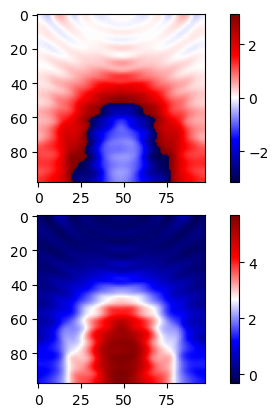

In [71]:
# psi = np.angle(dat_SYN[:,0,-1]*np.conj(dat_OBS[:,0,-1])).reshape(Nrz, Nrx)
# phi = unwrap(psi)

plt.subplot(211)
plt.imshow(psi, cmap="seismic")
plt.colorbar()
plt.subplot(212)
plt.imshow(phi, cmap="seismic")
plt.colorbar()


Text(5, 10, '(F)')

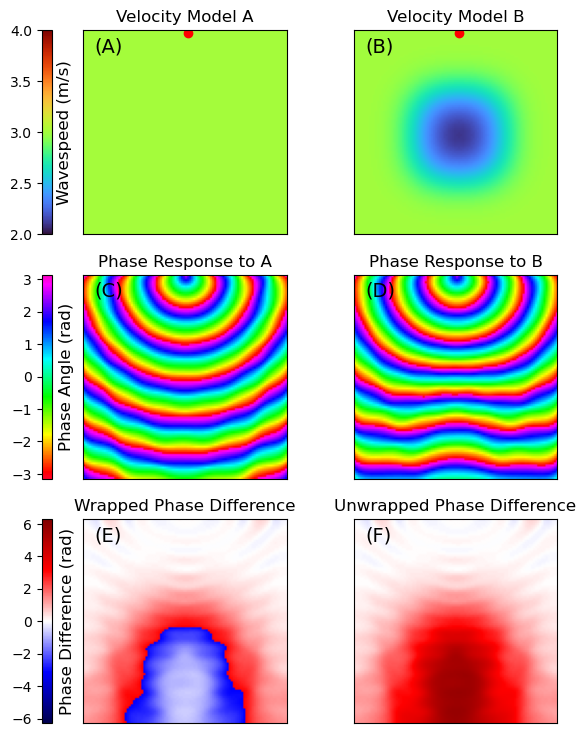

In [70]:
psi1 = np.angle(dat_SYN[:,j,k]).reshape(Nrz, Nrx)

fig, ax = plt.subplots(3, 2, figsize=(8,9), sharex=True, sharey=True)

im1 = ax[0,0].imshow(m, cmap="turbo", vmin=2.0, vmax=4.0)
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])
cbar0 = fig.colorbar(im1, ax=ax[0,:], location="left", pad=0.05)
cbar0.set_label('Wavespeed (m/s)', rotation=90, labelpad=-45, fontsize=12)
ax[0,0].set_title("Velocity Model A")
ax[0,0].scatter(s_x_inds*h, s_z_inds*h, marker="o", c="r")
ax[0,0].text(5, 10, "(A)", fontsize=14)

im2 = ax[0,1].imshow(m2, cmap="turbo", vmin=2.0, vmax=4.0)
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
ax[0,1].set_title("Velocity Model B")
ax[0,1].scatter(s_x_inds*h, s_z_inds*h, marker="o", c="r")
ax[0,1].text(5, 10, "(B)", fontsize=14)

im3 = ax[1,0].imshow(psi1, cmap="gist_rainbow")
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])
cbar1 = fig.colorbar(im3, ax=ax[1,:], location="left", pad=0.05)
cbar1.set_label('Phase Angle (rad)', rotation=90, labelpad=-45, fontsize=12)
ax[1,0].set_title("Phase Response to A")
ax[1,0].text(5, 10, "(C)", fontsize=14)

im4 = ax[1,1].imshow(psi0, cmap="gist_rainbow")
ax[1,1].set_xticks([])
ax[1,1].set_yticks([])
ax[1,1].set_title("Phase Response to B")
ax[1,1].text(5, 10, "(D)", fontsize=14)

im5 = ax[2,0].imshow(psi, cmap="seismic", vmin=-2*np.pi, vmax=2*np.pi)
ax[2,0].set_xticks([])
ax[2,0].set_yticks([])
cbar2 = fig.colorbar(im5, ax=ax[2,:], location="left", pad=0.05)
cbar2.set_label('Phase Difference (rad)', rotation=90, labelpad=-45, fontsize=12, color="k")
ax[2,0].set_title("Wrapped Phase Difference")
ax[2,0].text(5, 10, "(E)", fontsize=14)

im6 = ax[2,1].imshow(phi, cmap="seismic", vmin=-2*np.pi, vmax=2*np.pi)
ax[2,1].set_xticks([])
ax[2,1].set_yticks([])
ax[2,1].set_title("Unwrapped Phase Difference")
ax[2,1].text(5, 10, "(F)", fontsize=14)


In [12]:
# fig, ax = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=True)

# im1 = ax[0].imshow(psi, cmap="seismic", vmin=-2*np.pi, vmax=2*np.pi)
# ax[0].set_xticks([])
# ax[0].set_yticks([])
# fig.colorbar(im1, ax=ax[:], location="left", pad=0.025)
# ax[0].set_title("Wrapped Phase Difference")

# im2 = ax[1].imshow(phi, cmap="seismic", vmin=-2*np.pi, vmax=2*np.pi)
# ax[1].set_xticks([])
# ax[1].set_yticks([])
# ax[1].set_title("Unwrapped Phase Difference")

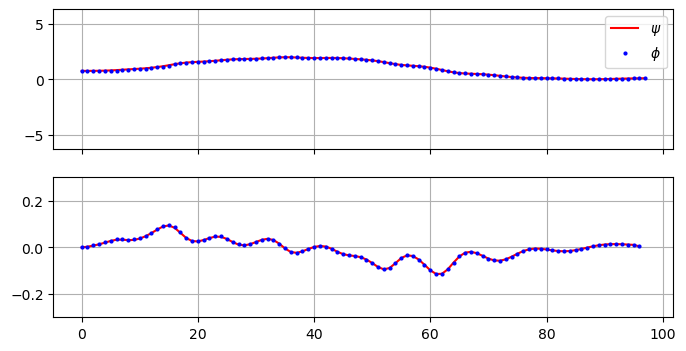

In [13]:
ig, ax = plt.subplots(2, 1, figsize=(8,4), sharex=True)

ax[0].plot(phi[:,60],"r-", label=r"$\psi$")
ax[0].plot(psi[:,60], "bo", markersize=2.0, label=r"$\phi$")
ax[0].set_ylim(-2.0*np.pi, 2.0*np.pi)
ax[0].grid()
ax[0].legend()

ax[1].plot(np.diff(phi[:,60]), "r-")
ax[1].plot(wrap(np.diff(psi[:,60])), "bo", markersize=2.0)
ax[1].set_ylim(-0.3, 0.3)
ax[1].grid()


# plt.plot(np.diff(psi[:,60]), "go", markersize=1.5)
# plt.plot(psi[60,:])
# plt.plot(phi[60,:],"r--")

In [14]:
# compute 1 L2 norm gradient

m = 1.0*m1

# initialize array of predicted dat
dat_SYN = np.zeros((Nr, Ns, N_freq), dtype=complex)
resid = np.zeros((Nr, Ns, N_freq), dtype=complex)

G_l2 = np.zeros(m.shape)

for k in range(N_freq):

	# get wavefield propogator matrix
	omega = freqs[k]*2*np.pi
	A = make_diff_opperator(m, Nx, Nz, h, omega)

	# Set up source Matrix
	f = np.zeros((Nm, Ns), dtype=complex)
	for i in range(Ns): 
		global_ind = np.ravel_multi_index((int(s_z_inds[i]), int(s_x_inds[i])), (Nz, Nx))
		f[global_ind, i] = 1.0

	# compute forward wavefield
	u = spsolve(A, f).reshape((Nm, Ns))

	# pull out predicted data
	for i in range(Nr): 
		for j in range(Ns): 
			global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
			dat_SYN[i,j,k] = u[global_ind,j]

	# compute redidual and adjoint source
	resid = (dat_SYN - dat_OBS)
	
	f_adj = np.zeros((Nm, Ns), dtype=complex)
	for i in range(Nr): 
		for j in range(Ns): 
			global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
			f_adj[global_ind,j] = (resid[i,j,k])

	# compute adjoint wavefield
	u_adj = spsolve(np.conj(A.T), f_adj).reshape((Nm, Ns))

	# correlate and sum over the forward and adjoint wavefields
	g_temp = np.sum(np.conj(u_adj) * u, axis=1)

	G_l2 += g_temp.reshape(m.shape).real * 2.0 * (omega**2) * (m**3)

G_l2 *= P0


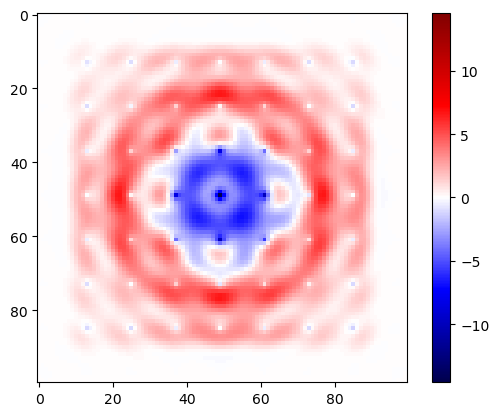

In [15]:
plt.imshow(G_l2, vmin=-np.max(np.abs(G_l2)), vmax=np.max(np.abs(G_l2)), cmap="seismic")
plt.colorbar()

In [16]:
# compute one phase unwrapped gradient

m = 1.0*m1

# initialize array of predicted dat
dat_SYN = np.zeros((Nr, Ns, N_freq), dtype=complex)
resid = np.zeros((Nr, Ns, N_freq), dtype=complex)

G_w = np.zeros(m.shape)

for k in range(N_freq):

	# get wavefield propogator matrix
	omega = freqs[k]*2*np.pi
	A = make_diff_opperator(m, Nx, Nz, h, omega)

	# Set up source Matrix
	f = np.zeros((Nm, Ns), dtype=complex)
	for i in range(Ns): 
		global_ind = np.ravel_multi_index((int(s_z_inds[i]), int(s_x_inds[i])), (Nz, Nx))
		f[global_ind, i] = 1.0

	# compute forward wavefield
	u = spsolve(A, f).reshape((Nm, Ns))

	# pull out predicted data
	for i in range(Nr): 
		for j in range(Ns): 
			global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
			dat_SYN[i,j,k] = u[global_ind,j]
			
	# unwrap data
	for j in range(Ns):
		psi = np.angle(dat_SYN[:,j,k]*np.conj(dat_OBS[:,j,k])).reshape(Nrz, Nrx)
		resid[:,j,k] = psi.flatten()
	
	# populate and adjoint source
	f_adj = np.zeros((Nm, Ns), dtype=complex)
	for i in range(Nr): 
		for j in range(Ns): 
			global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
			f_adj[global_ind,j] = np.conj(resid[i,j,k]/dat_SYN[i,j,k])

	# compute adjoint wavefield
	u_adj = spsolve(np.conj(A.T), f_adj).reshape((Nm, Ns))

	# correlate and sum over the forward and adjoint wavefields
	g_temp = np.sum(np.conj(u_adj) * u, axis=1)

	G_w += g_temp.reshape(m.shape).imag  * 2.0 * (omega**2) * (m**3)

G_w *= P0

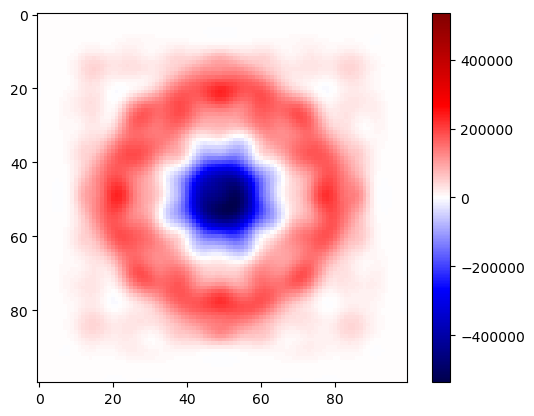

In [17]:
plt.imshow(G_w, vmin=-np.max(np.abs(G_w)), vmax=np.max(np.abs(G_w)), cmap="seismic")
plt.colorbar()

Text(5, 10, '(C)')

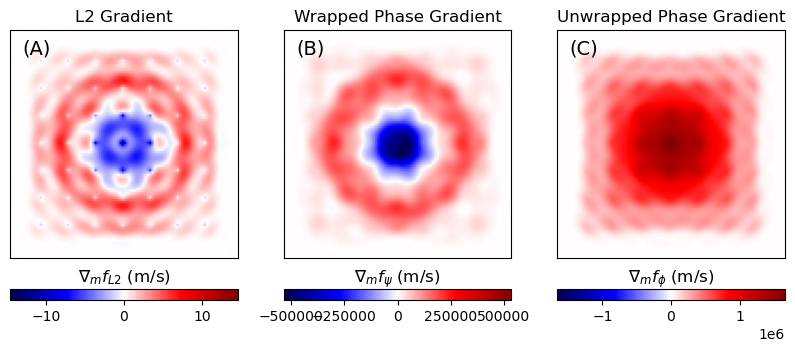

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(10,4))

im1 = ax[0].imshow(G_l2, cmap="seismic" ,vmin=-np.max(np.abs(G_l2)), vmax=np.max(np.abs(G_l2)))
ax[0].set_xticks([])
ax[0].set_yticks([])
cbar0 = fig.colorbar(im1, ax=ax[0], location="bottom", pad=0.1)
cbar0.set_label(r'$\nabla_m f_{L2}$ (m/s)', rotation=0, labelpad=-40, fontsize=12)
ax[0].set_title("L2 Gradient")
ax[0].text(5, 10, "(A)", fontsize=14)
# ax[0].scatter(s_x_inds*h, s_z_inds*h, marker="o", c="r")

im2 = ax[1].imshow(G_w, vmin=-np.max(np.abs(G_w)), vmax=np.max(np.abs(G_w)), cmap="seismic")
ax[1].set_xticks([])
ax[1].set_yticks([])
cbar1 = fig.colorbar(im2, ax=ax[1], location="bottom", pad=0.1)
cbar1.set_label(r'$\nabla_m f_{\psi}$ (m/s)', rotation=0, labelpad=-40, fontsize=12)
ax[1].set_title("Wrapped Phase Gradient")
ax[1].text(5, 10, "(B)", fontsize=14)

im3 = ax[2].imshow(G, vmin=-np.max(np.abs(G)), vmax=np.max(np.abs(G)), cmap="seismic")
ax[2].set_xticks([])
ax[2].set_yticks([])
cbar2 = fig.colorbar(im3, ax=ax[2], location="bottom", pad=0.1)
cbar2.set_label(r'$\nabla_m f_{\phi}$ (m/s)', rotation=0, labelpad=-40, fontsize=12)
ax[2].set_title("Unwrapped Phase Gradient")
ax[2].text(5, 10, "(C)", fontsize=14)

In [19]:
# get inital model
m = 1.0*m1
c_min = 2.0
c_max = 4.0
misfits = []
max_update = 0.1
N_iters = 20

# Do FWI starting with the initial model
for iter in range(N_iters):

	# initialize array of predicted dat
	dat_SYN = np.zeros((Nr, Ns, N_freq), dtype=complex)

	# initialize the gradient and preconditioner
	G = np.zeros(m.shape)
	P = np.zeros(m.shape)

	for k in range(N_freq):

		# get wavefield propogator matrix
		omega = freqs[k]*2*np.pi
		A = make_diff_opperator(m, Nx, Nz, h, omega)

		# Set up source Matrix
		f = np.zeros((Nm, Ns), dtype=complex)
		for i in range(Ns): 
			global_ind = np.ravel_multi_index((int(s_z_inds[i]), int(s_x_inds[i])), (Nz, Nx))
			f[global_ind, i] = 1.0

		# compute forward wavefield
		u = spsolve(A, f).reshape((Nm, Ns))

		# pull out predicted data
		for i in range(Nr): 
			for j in range(Ns): 
				global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
				dat_SYN[i,j,k] = u[global_ind,j]

		# compute redidual and adjoint source
		resid = (dat_OBS - dat_SYN)
		f_adj = np.zeros((Nm, Ns), dtype=complex)
		for i in range(Nr): 
			for j in range(Ns): 
				global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
				f_adj[global_ind,j] = resid[i,j,k]

		# compute adjoint wavefield
		u_adj = spsolve(np.conj(A.T), f_adj).reshape((Nm, Ns))

		# correlate and sum over the forward and adjoint wavefields
		g_temp = np.conj(u_adj) * u
		g_temp = np.sum(g_temp, axis=1).real
		# update the gradient
		G += -2*(omega**2)*np.reshape(g_temp, (Nz, Nx))/(m**3)

		# compute the preconditioner 
		# p_temp = np.conj(u)*u
		# p_temp = np.sum(p_temp, axis=1).real
		# P += np.reshape(p_temp, (Nz, Nx))

	# update the model
	# H = -P0*(G/P)
	H = -P0*G
	alpha = max_update/np.max(np.abs(H))
	m += alpha*H
	m = m.clip(c_min, c_max)

	# append the misfits
	misfits.append(np.sum(resid*np.conj(resid)).real)

	m_l2 = 1.0*m

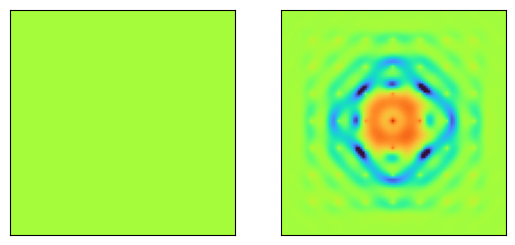

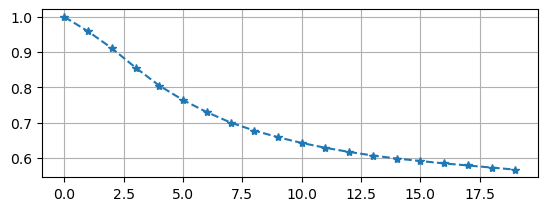

In [20]:
# plot results

plt.subplot(121)
plt.imshow(m1, cmap="turbo", vmin=c_min, vmax=c_max)
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(m_l2, cmap="turbo", vmin=c_min, vmax=c_max)
plt.xticks([])
plt.yticks([])
plt.show()

plt.subplot(211)
plt.plot(misfits/misfits[0], "*--")
plt.grid()

In [21]:
# do Unwrapped Phase inversion
m = 1.0*m1
c_min = 2.0
c_max = 4.0
misfits = []
max_update = 0.1
N_iters = 20

# Do FWI starting with the initial model
for iter in range(N_iters):

	# initialize array of predicted dat
	dat_SYN = np.zeros((Nr, Ns, N_freq), dtype=complex)

	# initialize the gradient and preconditioner
	G = np.zeros(m.shape)
	P = np.zeros(m.shape)

	for k in range(N_freq):

		# get wavefield propogator matrix
		omega = freqs[k]*2*np.pi
		A = make_diff_opperator(m, Nx, Nz, h, omega)

		# Set up source Matrix
		f = np.zeros((Nm, Ns), dtype=complex)
		for i in range(Ns): 
			global_ind = np.ravel_multi_index((int(s_z_inds[i]), int(s_x_inds[i])), (Nz, Nx))
			f[global_ind, i] = 1.0

		# compute forward wavefield
		u = spsolve(A, f).reshape((Nm, Ns))

		# pull out predicted data
		for i in range(Nr): 
			for j in range(Ns): 
				global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
				dat_SYN[i,j,k] = u[global_ind,j]

		# unwrap data
		for j in range(Ns):
			psi = np.angle(dat_SYN[:,j,k]*np.conj(dat_OBS[:,j,k])).reshape(Nrz, Nrx)
			phi = unwrap(psi, s_x_inds[j], s_z_inds[j])
			# phi = 1.0*psi
			resid[:,j,k] = phi.flatten()
		
		# populate and adjoint source
		f_adj = np.zeros((Nm, Ns), dtype=complex)
		for i in range(Nr): 
			for j in range(Ns): 
				global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
				f_adj[global_ind,j] = np.conj(resid[i,j,k]/dat_SYN[i,j,k])

		# compute adjoint wavefield
		u_adj = spsolve(np.conj(A.T), f_adj).reshape((Nm, Ns))

		# correlate and sum over the forward and adjoint wavefields
		g_temp = np.conj(u_adj) * u
		g_temp = np.sum(g_temp, axis=1).imag
		# update the gradient
		G += 2*(omega**2)*np.reshape(g_temp, (Nz, Nx))/(m**3)

		# # compute the preconditioner 
		# p_temp = np.conj(u)*u
		# p_temp = np.sum(p_temp, axis=1).real
		# P += np.reshape(p_temp, (Nz, Nx))

	# update the model
	# H = -P0*(G/P)
	H = -P0*G
	alpha = max_update/np.max(np.abs(H))
	m += alpha*H
	m = m.clip(c_min, c_max)

	# append the misfits
	misfits.append(np.sum(resid*np.conj(resid)).real)

m_uw = 1.0*m

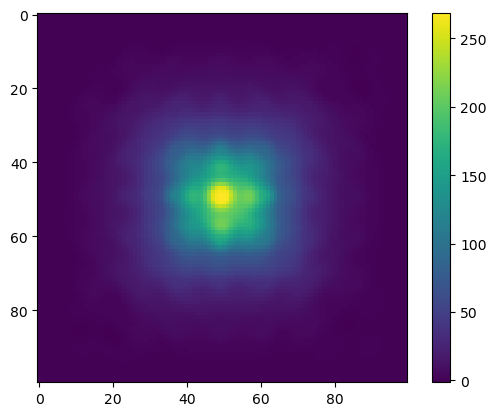

In [22]:
plt.imshow(G*P0)
plt.colorbar()

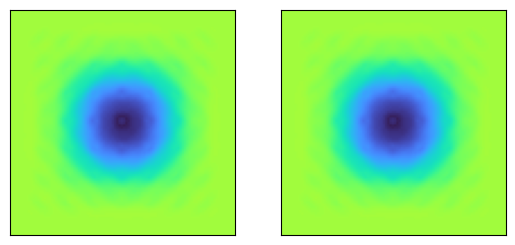

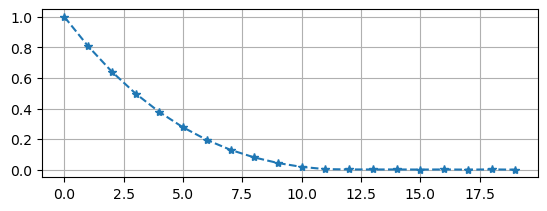

In [23]:
# # plot results

plt.subplot(121)
plt.imshow(m, cmap="turbo", vmin=c_min, vmax=c_max)
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(m_uw, cmap="turbo", vmin=c_min, vmax=c_max)
plt.xticks([])
plt.yticks([])
plt.show()

plt.subplot(211)
# plt.plot(np.log(misfits/misfits[0]), "*--")
plt.plot(misfits/misfits[0], "*--")
plt.grid()

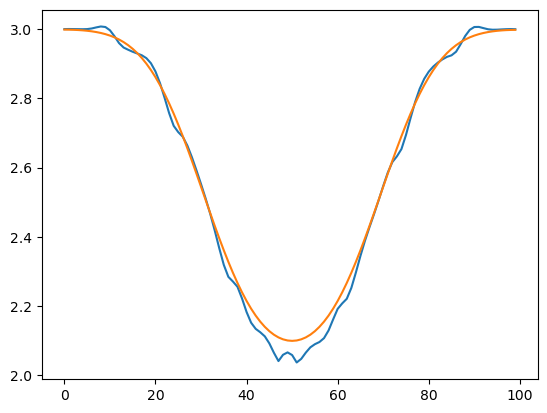

In [24]:
plt.plot(m[50,:])
plt.plot(m2[50,:])

In [25]:
# do Wrapped Phase inversion
m = 1.0*m1
c_min = 2.0
c_max = 4.0
misfits = []
max_update = 0.1
N_iters = 20

# Do FWI starting with the initial model
for iter in range(N_iters):

	# initialize array of predicted dat
	dat_SYN = np.zeros((Nr, Ns, N_freq), dtype=complex)

	# initialize the gradient and preconditioner
	G = np.zeros(m.shape)
	P = np.zeros(m.shape)

	for k in range(N_freq):

		# get wavefield propogator matrix
		omega = freqs[k]*2*np.pi
		A = make_diff_opperator(m, Nx, Nz, h, omega)

		# Set up source Matrix
		f = np.zeros((Nm, Ns), dtype=complex)
		for i in range(Ns): 
			global_ind = np.ravel_multi_index((int(s_z_inds[i]), int(s_x_inds[i])), (Nz, Nx))
			f[global_ind, i] = 1.0

		# compute forward wavefield
		u = spsolve(A, f).reshape((Nm, Ns))

		# pull out predicted data
		for i in range(Nr): 
			for j in range(Ns): 
				global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
				dat_SYN[i,j,k] = u[global_ind,j]

		# unwrap data
		for j in range(Ns):
			resid[:,j,k] = np.angle(dat_SYN[:,j,k]*np.conj(dat_OBS[:,j,k]))
		
		# populate and adjoint source
		f_adj = np.zeros((Nm, Ns), dtype=complex)
		for i in range(Nr): 
			for j in range(Ns): 
				global_ind = np.ravel_multi_index((int(r_z_inds[i]), int(r_x_inds[i])), (Nz, Nx))
				f_adj[global_ind,j] = np.conj(resid[i,j,k]/dat_SYN[i,j,k])

		# compute adjoint wavefield
		u_adj = spsolve(np.conj(A.T), f_adj).reshape((Nm, Ns))

		# correlate and sum over the forward and adjoint wavefields
		g_temp = np.conj(u_adj) * u
		g_temp = np.sum(g_temp, axis=1).imag
		# update the gradient
		G += 2*(omega**2)*np.reshape(g_temp, (Nz, Nx))/(m**3)

		# # compute the preconditioner 
		# p_temp = np.conj(u)*u
		# p_temp = np.sum(p_temp, axis=1).real
		# P += np.reshape(p_temp, (Nz, Nx))

	# update the model
	# H = -P0*(G/P)
	H = -P0*G
	alpha = max_update/np.max(np.abs(H))
	m += alpha*H
	m = m.clip(c_min, c_max)

	# append the misfits
	misfits.append(np.sum(resid*np.conj(resid)).real)

m_w = 1.0*m

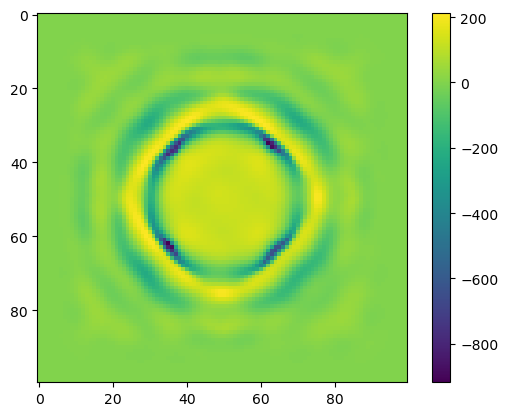

In [26]:
plt.imshow(H)
plt.colorbar()

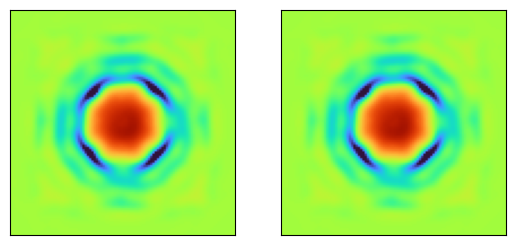

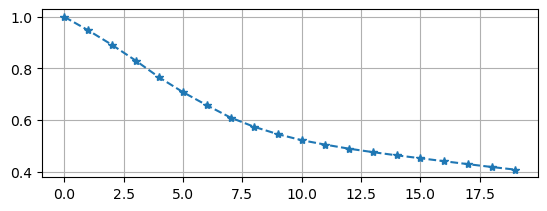

In [27]:
# plot results

plt.subplot(121)
plt.imshow(m, cmap="turbo", vmin=c_min, vmax=c_max)
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(m_w, cmap="turbo", vmin=c_min, vmax=c_max)
plt.xticks([])
plt.yticks([])
plt.show()

plt.subplot(211)
plt.plot(misfits/misfits[0], "*--")
plt.grid()

Text(5, 10, '(D)')

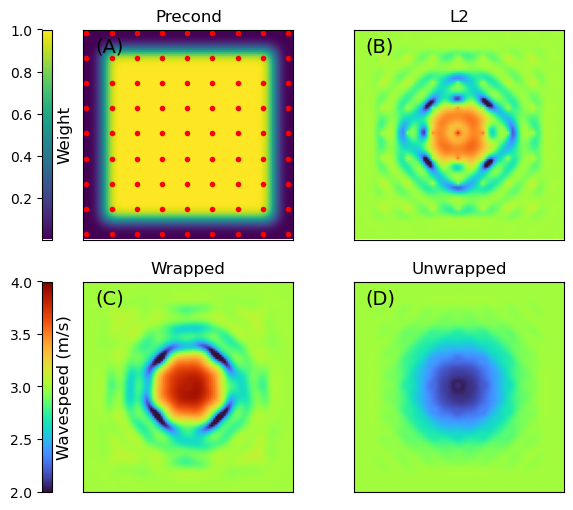

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(8,6), sharey=True, sharex=True)

im1 = ax[0,0].imshow(P0)
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])
cbar0 = fig.colorbar(im1, ax=ax[0,:], location="left", pad=0.05)
cbar0.set_label('Weight', rotation=90, labelpad=-45, fontsize=12)
ax[0,0].set_title("Precond")
ax[0,0].scatter(s_x_inds*h, s_z_inds*h, marker=".", c="r")
ax[0,0].text(5, 10, "(A)", fontsize=14)


# im1 = ax[0,0].imshow(m2, cmap="turbo", vmin=2.0, vmax=4.0)
# ax[0,0].set_xticks([])
# ax[0,0].set_yticks([])
# fig.colorbar(im1, ax=ax[0,:], location="left", pad=0.025)
# ax[0,0].set_title("Precond")

im2 = ax[0,1].imshow(m_l2, cmap="turbo", vmin=2.0, vmax=4.0)
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
# fig.colorbar(im2, ax=[ax[0,1]], location="right", pad=0.025,)
ax[0,1].set_title("L2")
ax[0,1].text(5, 10, "(B)", fontsize=14)

im3 = ax[1,0].imshow(m_w, cmap="turbo", vmin=2.0, vmax=4.0)
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])
cbar1 = fig.colorbar(im3, ax=ax[1,:], location="left", pad=0.05)
cbar1.set_label('Wavespeed (m/s)', rotation=90, labelpad=-45, fontsize=12)
ax[1,0].set_title("Wrapped")
ax[1,0].text(5, 10, "(C)", fontsize=14)

im4 = ax[1,1].imshow(m_uw, cmap="turbo", vmin=2.0, vmax=4.0)
ax[1,1].set_xticks([])
ax[1,1].set_yticks([])
# fig.colorbar(im4, ax=ax[1,:], location="right", pad=0.025)
ax[1,1].set_title("Unwrapped")
ax[1,1].text(5, 10, "(D)", fontsize=14)
